In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential, load_model
from keras.layers import Embedding, Dense, LSTM, Dropout, TimeDistributed, RepeatVector
from collections import Counter
# from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.losses import SparseCategoricalCrossentropy

2024-10-06 15:17:56.457416: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### reference
source: https://github.com/SayamAlt/English-to-French-Language-Translation-using-Seq2Seq-Modeling/blob/main/English_to_French_Translation_using_Seq2Seq.ipynb

In [2]:
df = pd.read_csv('../dataset/fra-eng/eng-french.csv')
df.head()

,English words/sentences,French words/sentences
0,Hi.,Salut!
1,Run!,Cours !
2,Run!,Courez !
3,Who?,Qui ?
4,Wow!,Ça alors !


In [3]:
df.shape

(175621, 2)

In [3]:
# Separating the English and French datasets
eng = df['English words/sentences']
fra = df['French words/sentences']

In [5]:
eng

0                                                       Hi.
1                                                      Run!
2                                                      Run!
3                                                      Who?
4                                                      Wow!
                                ...                        
175616    Top-down economics never works, said Obama. "T...
175617    A carbon footprint is the amount of carbon dio...
175618    Death is something that we're often discourage...
175619    Since there are usually multiple websites on a...
175620    If someone who doesn't know your background sa...
Name: English words/sentences, Length: 175621, dtype: object

In [4]:
eng_word_counter = Counter([word for sentence in eng for word in sentence.split()])
print("Total count of English words:",len([word for sentence in eng for word in sentence.split()]))
print("Count of distinct English words:",len(eng_word_counter))
print("10 most common English words:",list(zip(*eng_word_counter.most_common(10)))[0])


Total count of English words: 1082098
Count of distinct English words: 27393
10 most common English words: ('I', 'to', 'you', 'the', 'a', 'is', 'Tom', 'of', 'in', 'have')


In [6]:
fra_word_counter = Counter([word for sentence in fra for word in sentence.split()])
print("Total count of French words:",len([word for sentence in fra for word in sentence.split()]))
print("Count of distinct French words:",len(fra_word_counter))
print("10 most common French words:",list(zip(*fra_word_counter.most_common(10)))[0])

Total count of French words: 1177832
Count of distinct French words: 44918
10 most common French words: ('de', 'Je', '?', 'pas', 'que', 'à', 'ne', 'la', 'le', 'Il')


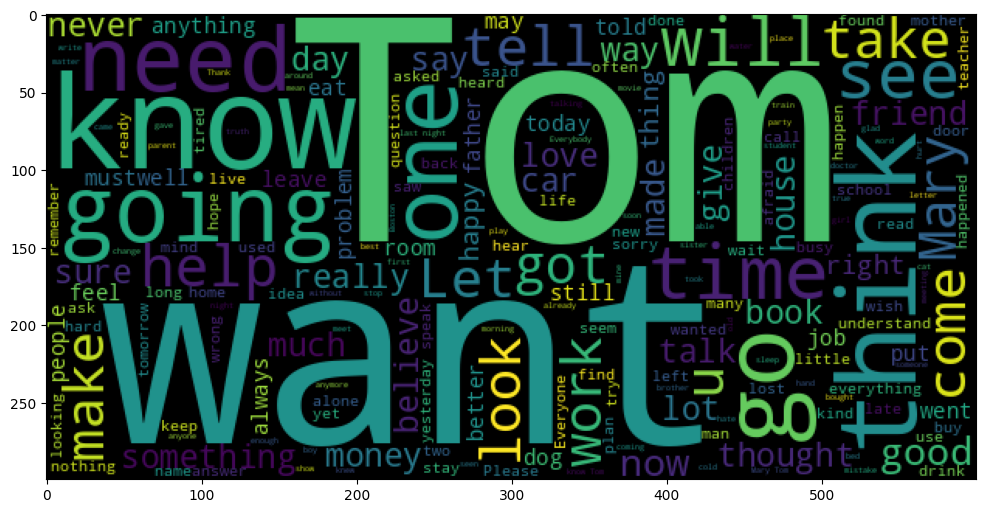

In [7]:
from wordcloud import WordCloud

plt.figure(figsize=(12,8))
wc = WordCloud(width=600,height=300).generate(' '.join(eng))
plt.imshow(wc)
plt.show();

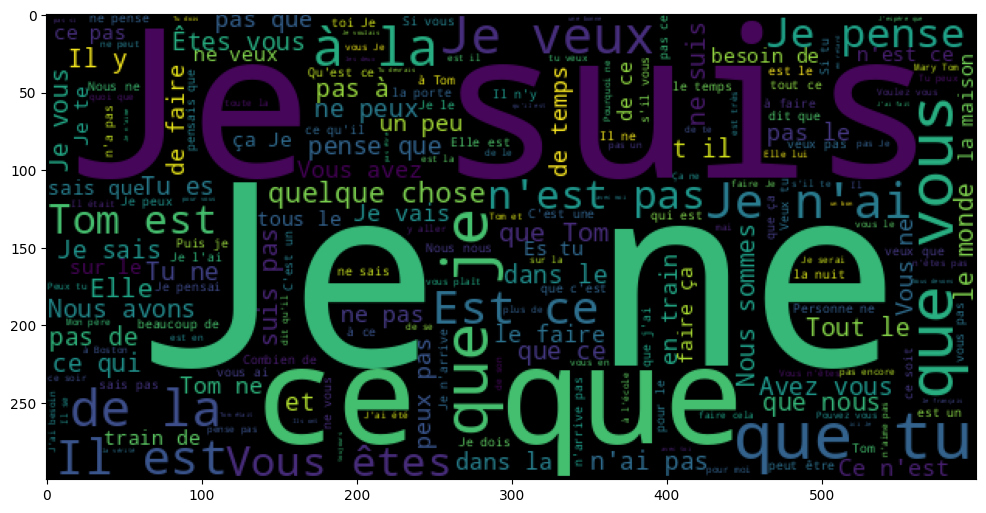

In [8]:
plt.figure(figsize=(12,8))
wc = WordCloud(width=600,height=300).generate(' '.join(fra))
plt.imshow(wc)
plt.show()

In [9]:
def word_count(line):
  return len(line.split())

In [10]:
df['English_word_count'] = df['English words/sentences'].apply(lambda x: word_count(x))
df['French_word_count'] = df['French words/sentences'].apply(lambda x: word_count(x))

In [11]:
df

,English words/sentences,French words/sentences,English_word_count,French_word_count
0,Hi.,Salut!,1,1
1,Run!,Cours !,1,2
2,Run!,Courez !,1,2
3,Who?,Qui ?,1,2
4,Wow!,Ça alors !,1,3
...,...,...,...,...
175616,"Top-down economics never works, said Obama. ""T...","« L'économie en partant du haut vers le bas, ç...",34,47
175617,A carbon footprint is the amount of carbon dio...,Une empreinte carbone est la somme de pollutio...,34,33
175618,Death is something that we're often discourage...,La mort est une chose qu'on nous décourage sou...,37,47
175619,Since there are usually multiple websites on a...,Puisqu'il y a de multiples sites web sur chaqu...,43,49


/var/folders/z6/2wz7jxb56936gt0mxv3lscnm0000gn/T/ipykernel_1450/1880454391.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['English_word_count'],ax=axes[0])
/var/folders/z6/2wz7jxb56936gt0mxv3lscnm0000gn/T/ipykernel_1450/1880454391.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['F

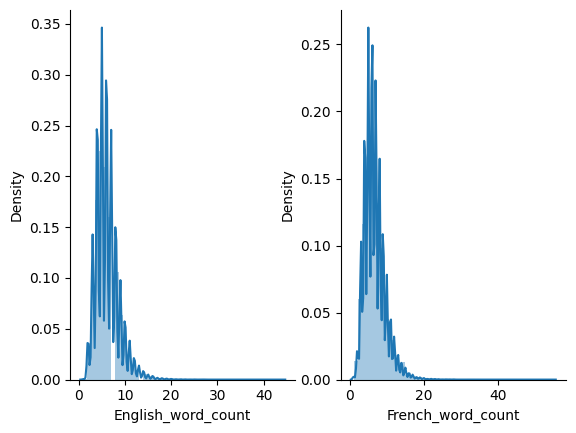

In [12]:
fig, axes = plt.subplots(nrows=1,ncols=2)
sns.distplot(df['English_word_count'],ax=axes[0])
sns.distplot(df['French_word_count'],ax=axes[1])
sns.despine()
plt.show();

In [33]:
def create_tokenizer(sentences):
  tokenizer = Tokenizer()
  tokenizer.fit_on_texts(sentences)
  return tokenizer

In [32]:
# tokeniz = create_tokenizer("I love you the most")
# print(tokeniz)

In [34]:
def max_sentence_length(lines):
  return max(len(sentence.split()) for sentence in lines)

In [35]:
def encode_sequences(tokenizer,sentences,max_sent_len):
  text_to_seq = tokenizer.texts_to_sequences(sentences) # encode sequences with integers
  text_pad_seq = pad_sequences(text_to_seq,maxlen=max_sent_len,padding='post') # pad sequences with 0
  return text_pad_seq

In [36]:
# Prepare English tokenizer
eng_tokenizer = create_tokenizer(eng)
eng_vocab_size = len(eng_tokenizer.word_index) + 1
max_eng_sent_len = max_sentence_length(eng)
print("English vocabulary size:", eng_vocab_size)
print("Maximum length of English sentences:", max_eng_sent_len)

English vocabulary size: 14532
Maximum length of English sentences: 44


In [37]:
# Prepare French tokenizer
fra_tokenizer = create_tokenizer(fra)
fra_vocab_size = len(fra_tokenizer.word_index) + 1
max_fra_sent_len = max_sentence_length(fra)
print("French vocabulary size:", fra_vocab_size)
print("Maximum length of French sentences:", max_fra_sent_len)

French vocabulary size: 30661
Maximum length of French sentences: 55


In [38]:
max_eng_sent_len = 22
max_fra_sent_len = 22

In [39]:
# Perform encoding of sequences
X = encode_sequences(eng_tokenizer,eng,max_eng_sent_len)
y = encode_sequences(fra_tokenizer,fra,max_fra_sent_len)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.15,shuffle=True,random_state=101)

In [41]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, RepeatVector, TimeDistributed, Dense, Dropout

def create_model(src_vocab_size, dest_vocab_size, src_timesteps, dest_timesteps, no_units):
    model = Sequential()
    model.add(Embedding(src_vocab_size, no_units, input_length=src_timesteps, mask_zero=True))
    model.add(LSTM(no_units))
    model.add(RepeatVector(dest_timesteps))
    model.add(LSTM(no_units, return_sequences=True))
    model.add(TimeDistributed(Dense(1024, activation='relu')))
    model.add(Dropout(0.2))
    model.add(TimeDistributed(Dense(dest_vocab_size, activation='softmax')))
  
    return model


In [42]:
print("eng_vocab_size", eng_vocab_size)
print(fra_vocab_size, max_eng_sent_len, max_fra_sent_len)
model = create_model(eng_vocab_size,fra_vocab_size,max_eng_sent_len,max_fra_sent_len,512)
model.summary()

eng_vocab_size 14532
30661 22 22


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_5 (RepeatVector)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [44]:
model.compile(loss=SparseCategoricalCrossentropy(),optimizer='rmsprop',metrics=['accuracy'])

In [45]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_5 (RepeatVector)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [46]:
es = EarlyStopping(monitor='val_accuracy',patience=3,mode='max',verbose=1)
lr = ReduceLROnPlateau(monitor='val_accuracy',patience=2,mode='max',verbose=1,factor=0.1,min_lr=0.001)

In [ ]:
### training

In [47]:
r = model.fit(X_train,
              y_train.reshape(y_train.shape[0],y_train.shape[1],1),
              epochs=5,
              batch_size=512,
              callbacks=[es,lr],
              validation_data=(X_test,y_test.reshape(y_test.shape[0],y_test.shape[1],1))
              )

Epoch 1/5
292/292 ━━━━━━━━━━━━━━━━━━━━ 6889s 24s/step - accuracy: 0.6859 - loss: 3.3198 - val_accuracy: 0.7111 - val_loss: 2.1166 - learning_rate: 0.0010
Epoch 2/5
  4/292 ━━━━━━━━━━━━━━━━━━━━ 2:43:07 34s/step - accuracy: 0.7152 - loss: 2.0827

KeyboardInterrupt: 

In [50]:
model.save("one-epoch-eng-fr.keras")

In [51]:
plt.figure(figsize=(12,8))
plt.plot(r.history['loss'],'r',label='train loss')
plt.plot(r.history['val_loss'],'b',label='test loss')
plt.xlabel('No. of Epochs')
plt.ylabel('Loss')
plt.title('Loss Graph')
plt.legend();

NameError: name 'r' is not defined

<Figure size 1200x800 with 0 Axes>